## Classic Machine Learning Template
_Using `INSERT MODEL HERE`_

<br>
<br>



### Dataset: [INSERT DATASET HERE](https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data)

|Parameter|Description|
|---|---|
|Shape|`45k rows, 23 columns`|
|Target Variable|`loan_status`|
|Method:|`LogisticRegression`
|Extra Tools:|`None`|

<br>

<i>


<div style="border: 3px dashed white; padding: 50px; box-sizing: border-box;">

<strong style='color:red ; background-color:black;'> 

#### Disclosure: 

-- Explain why you used AI and the model--

#### Prompt:

-- Write prompt -- 

</strong>


</div>


#### Column Descriptions:


| Column | Description |
|---|---|
| column_name1 | Age of the person |
| column_name2 | Gender of the person |



<br>

#### Summary: 

Explain the purpose of the notebook here.


<br>
<br>

<i>

#### Results:

Add screenshot of results
</i>

<br>
<br>


---

## Code:

#### Imports and Data Loading

In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline
import joblib

# Additional metrics ONLY for classification

# CLASSIFICATION
# from sklearn.metrics import classification_report
# from sklearn.metrics import confusion_matrix
# from sklearn.metrics import accuracy_score
# from sklearn.metrics import roc_auc_score

# REGRESSION
# from sklearn import metrics

# Go away warnings
import warnings
warnings.filterwarnings("ignore")

# Loading dataframe
df = pd.read_csv("../datasets/loan_data.csv")
df.head(3)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1


---

### Data Cleaning

|Step|Description|
|---|---|
|1|<bold style="background:yellow;color:black;"> Data Cleaning </bold>|
|2| Transformation|
|3| ML Training & Metrics|
|4| Tester Row Values|
|5| Personal Analysis |
|6| Advanced Tasks|

#### Checking the shape


In [177]:
# Checking the shape
df.shape

# 45,000 rows
# 23 columns

(45000, 14)

#### Handling Duplicates


In [178]:
# Checking duplicates
df.duplicated().sum()

np.int64(0)

#### Handling Missing Values

In [179]:
# Checking NaN values
df.isna().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

#### Checking For Isolated Categorical Cases

<i> 

In the cells below, we'll check the categorical column's value counts. If there isn't enough cases of a certain value, we drop it. I made an image which describes why. Steven is included.

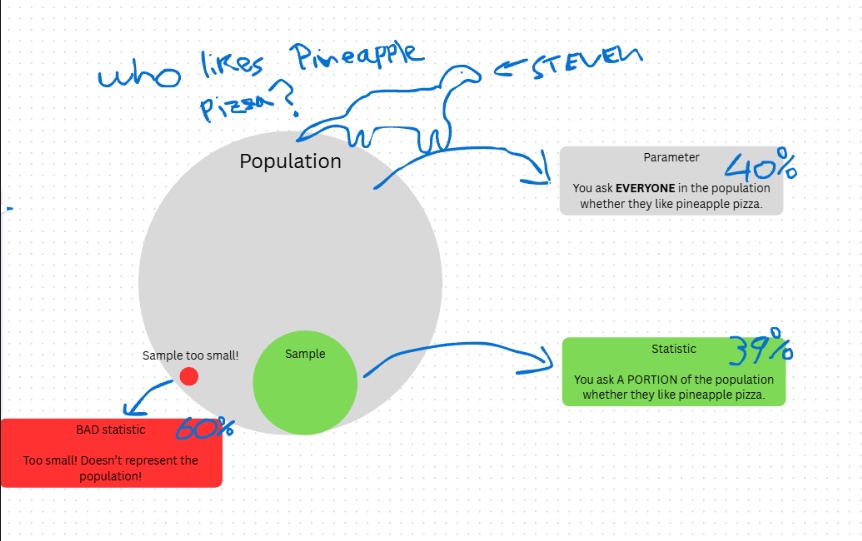

`Categorical Column`

In [ ]:
# Checking column's value counts. Can we find any isolated cases?
df['categorical_column'].value_counts()

person_education
Bachelor       13399
Associate      12028
High School    11972
Master          6980
Doctorate        621
Name: count, dtype: int64

#### Transforming Columns to Numbers

<i>

Now, let's encode all the string columns to numbers.

##### Categorical

In [ ]:
# We'll be turning all these into binary numeric column.
categorical_columns = ["column1", "column2", "column3"]

# OneHotEncoder to transform each categorical to separate, binary numeric.
for column in categorical_columns:
    encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
    one_hot_encoded = encoder.fit_transform(df[[column]]).astype(int)
    df = pd.concat([df.drop(columns=[column]), one_hot_encoded], axis=1)
    
# Dropping one column from each categorical variable.
df = df.drop([
    "column1_case3",
    "column2_case3",
    "column3_case3",
], axis=1)

#### Binary Columns

In [ ]:
from sklearn.preprocessing import LabelEncoder

# If you have a binary datatype column, this will convert it into numbers.
variables = ['column4', 'column5']

encoder = LabelEncoder()
df[variables] = df[variables].apply(encoder.fit_transform)

# For `previous_loan_defaults_on_file` : No=0, Yes=1
# For `person_gender` : Female=0, Male=1

#### Ordinal Variables

In [ ]:
# Creating a dict for all the ordinal values of a column
category_mapper = {'Small':0,
                   'Medium':1,
                   'Large':2
}

# Use the hashmap approach to map encode columnar values.
df['Size'] = df['Size'].map(category_mapper)

---

### Transformation & Feature Engineering

|Step|Description|
|---|---|
|1| Data Cleaning |
|2|<bold style="background:yellow;color:black;"> Transformation </bold>|
|3| ML Training & Metrics|
|4|Tester Row Values|
|5| Personal Analysis |
|6| Advanced Tasks|

#### Checking distributions

<i>

Let's now look at the distributions of both the target variable and its' features. We're going to determine if these features need transformations. 

##### Target Variable

In [ ]:
# Checking the target variable's distribution
df['target_variable'].value_counts()

loan_status
0    35000
1    10000
Name: count, dtype: int64

##### Features

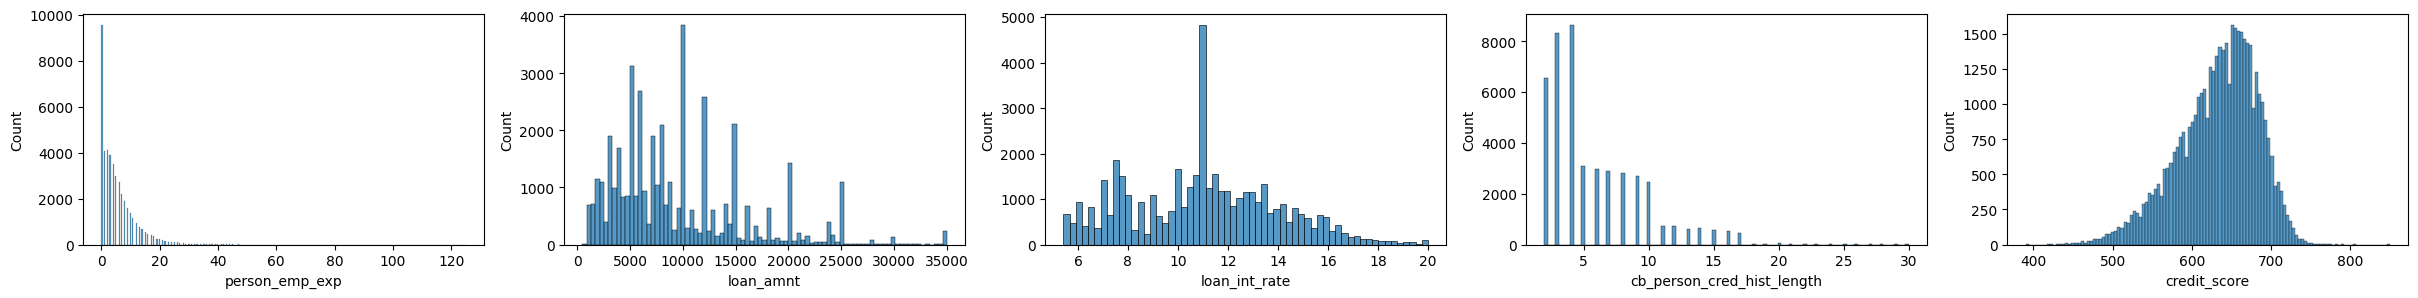

In [187]:
# Makes a loop that shows the distributions for every possible feature.

# Create a dataframe without the target variable.
features = df[["person_emp_exp","loan_amnt",'loan_int_rate', 'cb_person_cred_hist_length','credit_score']]

# Get the amount of columns. Used to say how many plots we need
len_columns = len(features.columns)

# Create a canvas, this will be where the plots go into.
fig, axes = plt.subplots(1, len_columns, figsize=(30, 3))

# For each plot in the index...
for index, feature in enumerate(features.columns): 
    # Get the place where the plot goes into...
    plot_num = index
    # Make a histplot, tell it where the plot goes, and which feature is needed.
    sns.histplot(features, x=feature, ax=axes[plot_num])  

---

### ML Training & Metrics

|Step|Description|
|---|---|
|1| Data Cleaning |
|2| Transformation|
|3| <bold style="background:yellow;color:black;">ML Training & Metrics </bold>|
|4| Tester Row Values|
|5| Personal Analysis |
|6| Advanced Tasks|

#### Training & Fitting Model

<i> Train/test split and fitting 

In [ ]:
# Defining dependent, independent variables.
X = df.drop(['target_variable'], axis=1)
y = df['target_variable']

# train/test-split.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=101)

# create the model and train it with the data
model = make_pipeline(StandardScaler(), LogisticRegression())
model.fit(X_train, y_train)

# Save the model using joblib
joblib.dump(model, "../models/ex2_main.pkl")

# we need to create test predictions based on our earlier reserved test dataset
# this data has never been seen by the model by now
predictions = model.predict(X_test)

# print the classification report based on true values and predictions
print(classification_report(y_test, predictions))

# get overall accuracy of the model and print it
acc = accuracy_score(y_test, predictions)
print("\nModel overall accuracy: {:.2f}%".format(acc * 100))

# see the confusion matrix
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='g')

['models/ex2_main.pkl']

#### Predict X_test, accuracy metrics

<i>
This will create metrix and a confusion matrix

In [195]:
# The AUC score is a super sensitive metric
# you often get low scores, even 0.5

# in binary logistic regression, AUC values are often interpreted as follows:
# A binary classifier is useful only when it achieves ROC-AUC score greater than 0.5 and as near to 1 as possible. 
# If a classifier yields a score less than 0.5, it simply means that the model is performing worse 
# than a random classifier, and therefore is useless.

# In multinomial logistic regression , AUC values are often interpreted as follows: 
# 0.5-0.6 (failed)
# 0.6-0.7 (worthless)
# 0.7-0.8 (poor)
# 0.8-0.9 (good)
# > 0.9 (excellent)

# basically 0.5 means you could get the same result with just random guessing
roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

# Decent metrics.

0.9516572978257262

---

#### Creating a Tester Row

|Step|Description|
|---|---|
|1| Data Cleaning |
|2| Transformation|
|3| ML Training & Metrics|
|4| <bold style="background:yellow;color:black;">Tester Row Values</bold>|
|5| Personal Analysis |
|6| Advanced Tasks|

In [ ]:
# Creating a tester row to check if it works as expected. 
tester_row = {
    'person_age': 20,
    'person_income': 30000,
    'person_emp_exp': 4,
    'loan_amnt': 6000,
    'loan_int_rate': 9,
    'loan_percent_income': 0.88,
    'cb_person_cred_hist_length': 2.0,
    'previous_loan_defaults_on_file': 0,
    'person_home_ownership_MORTGAGE': 0,
    'person_home_ownership_OWN': 1,
    'loan_intent_DEBTCONSOLIDATION': 1,
    'loan_intent_EDUCATION': 0,
    'loan_intent_HOMEIMPROVEMENT': 0,
    'loan_intent_MEDICAL': 0,
    'loan_intent_PERSONAL': 0
}

tester_row = pd.DataFrame([tester_row])
result = model.predict(tester_row)[0]

if result == 0:
    result = "Loan denied"
else:
    result = "Loan Approved"

print(result)

# I've used a number of different tests here. I tried out the loan amount, person_income, and loan_int_rate.
# These were the highest factors that could change the decision between 'approved' and 'denied'

# It all works as expected.

# Next time, I'll likely make a function for this and use assertations. It makes a bit more sense that way.

Loan Approved


---

### Personal Analysis

|Step|Description|
|---|---|
|1| Data Cleaning |
|2| Transformation|
|3| ML Training & Metrics|
|4|Tester Row Values|
|5|<bold style="background:yellow;color:black;"> Personal Analysis</bold>|
|6| Advanced Tasks|

### Thoughts:

<i>

The result was hardly optimized but achieved good results. I will give my theories behind that now.

</i>


### Theory:

<i>

This bank likely has some screening algorithm which is easily picked up by machines. The algorithm also must have been quite straightforward and not terribly complicated -- Hence why this model picked up on it quite easily. The data was also quite simple to work with (clean). Unfortunately I don't have a tremendous amount of other insight about the results of the data. I'll likely do a couple of extra exercises to experiment a bit with other datasets.

</i>

---

### Advanced Tasks

|Step|Description|
|---|---|
|1| Data Cleaning |
|2| Transformation|
|3| ML Training & Metrics|
|4| Tester Row Values|
|5| Personal Analysis |
|6| <bold style="background:yellow;color:black;">Advanced Tasks</bold> |